# Oversampling

### Load Dataset Lokal

In [5]:
import pandas as pd

# Load dataset CSV lokal
df = pd.read_csv("ecoli2.csv")

# Tampilkan 5 baris pertama untuk memastikan data berhasil dimuat
print()
print("="*80)
print("---5 baris pertama dataset:---")
print("="*80)
print(df.head())
print()

# Informasi dataset
print("="*60)
print("\nInfo dataset:")
print("="*60)
print(df.info())

# Statistik deskriptif
print("="*60)
print("\nStatistik deskriptif:")
print("="*60)
print(df.describe())



---5 baris pertama dataset:---
   id protein_name   mcg   gvh   lip  chg   aac  alm1  alm2 localization_class
0   1    AAT_ECOLI  0.49  0.29  0.48  0.5  0.56  0.24  0.35                 cp
1   2   ACEA_ECOLI  0.07  0.40  0.48  0.5  0.54  0.35  0.44                 cp
2   3   ACEK_ECOLI  0.56  0.40  0.48  0.5  0.49  0.37  0.46                 cp
3   4   ACKA_ECOLI  0.59  0.49  0.48  0.5  0.52  0.45  0.36                 cp
4   5    ADI_ECOLI  0.23  0.32  0.48  0.5  0.55  0.25  0.35                 cp


Info dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  336 non-null    int64  
 1   protein_name        336 non-null    object 
 2   mcg                 336 non-null    float64
 3   gvh                 336 non-null    float64
 4   lip                 336 non-null    float64
 5   chg                 336 n

### Memilih Fitur & Target

In [6]:
# Pilih kolom fitur numerik
X = df[["mcg","gvh","lip","chg","aac","alm1","alm2"]].values

# Target adalah kelas protein
y = df["localization_class"].astype(str)

# Tampilkan dimensi
print("Dimensi fitur X:", X.shape)
print("Dimensi target y:", y.shape)


Dimensi fitur X: (336, 7)
Dimensi target y: (336,)


### Encode Target Kelas

LabelEncoder mengubah target string menjadi angka agar bisa digunakan algoritma ML. Dimana saya menampilkan mapping agar mudah diketahui kelas mana yang diwakili angka berapa.

In [7]:
from sklearn.preprocessing import LabelEncoder

# Encode target menjadi angka
le = LabelEncoder()
y_enc = le.fit_transform(y)

# Tampilkan mapping kelas
print("Mapping kelas ke angka:")
for cls, val in zip(le.classes_, range(len(le.classes_))):
    print(f"{cls} -> {val}")


Mapping kelas ke angka:
cp -> 0
im -> 1
imL -> 2
imS -> 3
imU -> 4
om -> 5
omL -> 6
pp -> 7


### PCA ke 2 Dimensi

In [8]:
from sklearn.decomposition import PCA

# PCA 2 dimensi
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Lihat rasio variansi yang dijelaskan
print("persentase variansi data asli (2 komponen pertama):", pca.explained_variance_ratio_)


persentase variansi data asli (2 komponen pertama): [0.5161681 0.2442034]


### Scatter Plot PCA Data Asli

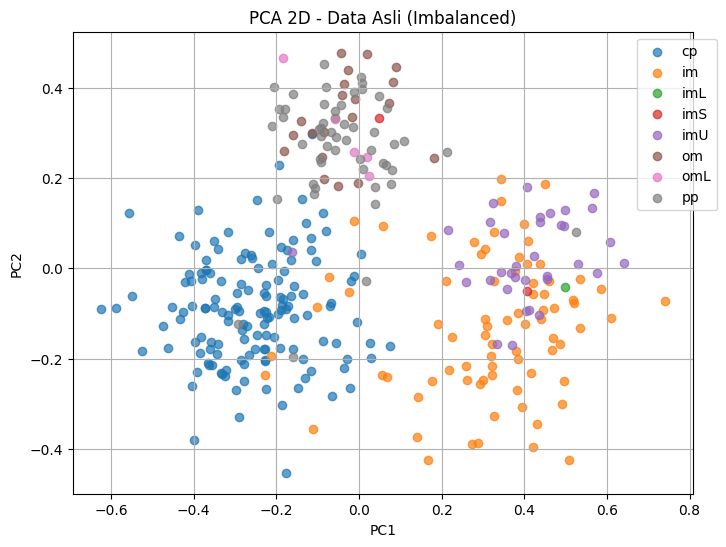

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# Loop per kelas
for cls in range(len(le.classes_)):
    plt.scatter(
        X_pca[y_enc==cls, 0], 
        X_pca[y_enc==cls, 1], 
        alpha=0.7, 
        label=le.classes_[cls]
    )

plt.title("PCA 2D - Data Asli (Imbalanced)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(bbox_to_anchor=(1.05,1))
plt.grid(True)
plt.show()


### Melakukan penyeimbangan data menggunakan ADASYN

#### 1. Menghitung jumlah sampel mayoritas & minoritas

Hasilnya pada mayoritas dan minoritas ini untuk nilai 0 adalah label numerik untuk kelas mayoritas (y_enc), yang biasanya hasil dari LabelEncoder dan angka 143 adalah jumlah sampel di kelas mayoritas tersebut. Begitu juga pada nilai 2 adalah label numerik untuk kelas minoritas dan angka 2 juga adalah jumlah sampel di kelas minoritas.

Jadi 0 dan 2 bukan jumlah, tapi kode/label kelas.

In [11]:
import numpy as np

# Hitung jumlah tiap kelas
classes, counts = np.unique(y_enc, return_counts=True)
major_class = classes[np.argmax(counts)]
minor_class = classes[np.argmin(counts)]

print("Mayoritas:", major_class, counts.max())
print("Minoritas:", minor_class, counts.min())

# Total sampel sintetis yang akan dibuat
G = counts.max() - counts.min()
print("Jumlah sampel sintetis yang akan dibuat:", G)


Mayoritas: 0 143
Minoritas: 2 2
Jumlah sampel sintetis yang akan dibuat: 141


#### 2. Mencari tetangga minoritas (KNN)

Pada hasil neighbors menunjukkan tetangga terdekat untuk setiap sampel minoritas: [[1], [0]] 

- Dimana untuk sampel minoritas pertama (index 0) adalah tetangga terdekatnya adalah sampel minoritas kedua (index 1).
- Dan untuk sampel minoritas kedua (index 1) →adalah tetangga terdekatnya adalah sampel minoritas pertama (index 0)

Karena hanya ada 2 sampel minoritas, tiap sampel hanya punya satu tetangga minoritas yang lain.

In [12]:
from sklearn.neighbors import NearestNeighbors

# Ambil data kelas minoritas
X_min = X[y_enc==minor_class]

# Tentukan jumlah tetangga K
K = min(5, len(X_min)-1)
K = max(K, 1)  # aman jika minoritas < 5

# Hitung tetangga untuk setiap titik minoritas
nn = NearestNeighbors(n_neighbors=K+1)  # +1 karena termasuk dirinya sendiri
nn.fit(X_min)
distances, neighbors = nn.kneighbors(X_min)
neighbors = neighbors[:,1:]  # buang diri sendiri
print("Tetangga minoritas (indices):\n", neighbors)


Tetangga minoritas (indices):
 [[1]
 [0]]


#### 3. Menghitung hardness ratio r_i & bobot w_i

Hardness ratio r_i adalah menilai “kesulitan” tiap titik minoritas.
- Nilai mendekati 0 → titik mudah diklasifikasikan (tetangga mayoritas sedikit)
- Nilai mendekati 1 → titik sulit diklasifikasikan (banyak tetangga mayoritas)

Dan di sini ini ada [0.01, 0.01] dimana kedua titik minoritas sangat mudah karena hampir semua tetangga minoritas.

Bobot w_i adalah normalisasi r_i agar total bobot = 1.
- [0.5, 0.5] → kedua titik minoritas dianggap sama penting untuk membuat sampel sintetis.

Dan untuk jumlah sampel sintetis per titik g_i adalah berapa banyak data sintetis yang akan dibuat dari tiap titik minoritas.
- [70, 70] ini adalah dari tiap titik minoritas akan dibuat 70 sampel sintetis, total 140 sampel baru (agar seimbang dengan kelas mayoritas).

Jadi intinya: semakin sulit titik minoritas diklasifikasikan, semakin banyak sampel sintetis dibuat dari titik itu.

In [13]:
r = []

# KNN dari semua data untuk hitung hardness
nn_full = NearestNeighbors(n_neighbors=K)
nn_full.fit(X)

for xi in X_min:
    _, nbr_idx = nn_full.kneighbors([xi])
    nbr_classes = y_enc[nbr_idx[0]]
    ri = np.sum(nbr_classes == major_class) / K
    # jika semua tetangga minoritas, beri nilai kecil agar tidak nol
    if ri == 0:
        ri = 0.01
    r.append(ri)

r = np.array(r)

# Normalisasi bobot w_i
w = r / r.sum()

# Jumlah sampel sintetis per titik minoritas
g = np.round(w * G).astype(int)

print("Hardness ratio r_i:", r)
print("Bobot w_i:", w)
print("Jumlah sampel sintetis per titik g_i:", g)


Hardness ratio r_i: [0.01 0.01]
Bobot w_i: [0.5 0.5]
Jumlah sampel sintetis per titik g_i: [70 70]


#### 4. Mengenerate sampel sintetis

Pada tahap ini adalah data sintetis dibuat dari titik minoritas dengan variasi acak menuju tetangga minoritas, untuk menyeimbangkan dataset. 

In [17]:
synthetic_samples = []
np.random.seed(42)

for i, xi in enumerate(X_min):
    for _ in range(g[i]):
        # pilih tetangga acak dari minoritas
        neighbor_idx = np.random.choice(neighbors[i])
        xzi = X_min[neighbor_idx]
        # random lambda
        lam = np.random.rand()
        # buat sampel baru
        x_new = xi + lam*(xzi - xi)
        synthetic_samples.append(x_new)

synthetic_samples = np.array(synthetic_samples)
print("Jumlah sampel sintetis dihasilkan:", synthetic_samples.shape[0])


Jumlah sampel sintetis dihasilkan: 140


#### 5. Menggabungkan data asli + sintetis

Data asli sebelum ADASYN memiliki 336 baris (sampel) dan 7 kolom (fitur). Sedangkan Setelah ADASYN, data menjadi 476 baris, artinya 140 sampel sintetis telah ditambahkan untuk menyeimbangkan kelas minoritas. dan untuk jumlah kolom tetap 7 karena fitur tidak berubah. Dimana pada tahap ini ADASYN menambah data minoritas sehingga dataset menjadi lebih seimbang tanpa mengubah jumlah fitur.

In [18]:
X_balanced = np.vstack([X, synthetic_samples])
y_balanced = np.hstack([y_enc, np.array([minor_class]*synthetic_samples.shape[0])])

print("Shape data sebelum ADASYN:", X.shape)
print("Shape data setelah ADASYN:", X_balanced.shape)


Shape data sebelum ADASYN: (336, 7)
Shape data setelah ADASYN: (476, 7)


### Plotting Data Hasil ADASYN dengan PCA

#### 1. Mentransformasi PCA ke 2 dimensi

In [19]:
from sklearn.decomposition import PCA

# Buat PCA ke 2 dimensi
pca = PCA(n_components=2)

# Transformasi data asli + sintetis
X_pca = pca.fit_transform(X_balanced)

print("Rasio variansi yang dijelaskan (2 komponen pertama):", pca.explained_variance_ratio_)


Rasio variansi yang dijelaskan (2 komponen pertama): [0.46473599 0.28181033]


- PCA(n_components=2) menurunkan dimensi data dari banyak fitur menjadi 2D agar bisa diplot.

- fit_transform mengubah seluruh data (X_balanced) menjadi koordinat PCA.

#### 2. Memberikan Tanda data asli & sintetis

Jumlah data sintetis dari synthetic_samples.shape[0]. Memberikan tanda data terakhir sebagai sintetis (True), sisanya asli (False).

In [20]:
# Buat array boolean untuk menandai data sintetis
is_synthetic = np.zeros(X_balanced.shape[0], dtype=bool)
is_synthetic[-synthetic_samples.shape[0]:] = True  # bagian terakhir adalah sintetis


#### 3. Membuat plot data dengan scatter

Pada data asli Data asli berwarna (biru) yang mana sudah tersebar di area utama PCA, yang menunjukkan distribusi kelas mayoritas dan minoritas sebelum oversampling. Dan untuk Data sintetis yang warna (merah ×) ini berada di tepi kiri plot, menduplikasi area minoritas, tapi terlihat terkonsentrasi di satu garis, yang mana ADASYN menghasilkan sampel sintetis yang cukup linear mengikuti arah minoritas di PCA.

Distribusi kelasnya oversampling berhasil menambah jumlah minoritas dari sangat sedikit menjadi lebih seimbang, tapi penyebaran sintetis tidak terlalu menyebar luas, lebih menumpuk di sekitar data minoritas asli.

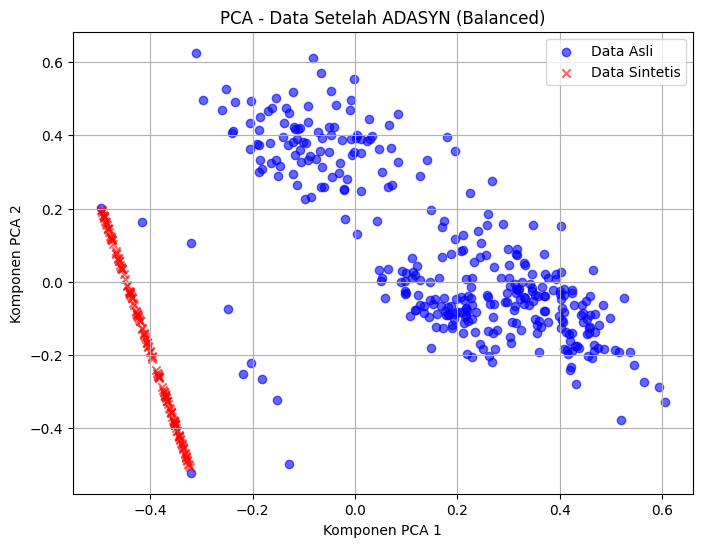

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# Plot data asli
plt.scatter(
    X_pca[~is_synthetic, 0],  # X koordinat
    X_pca[~is_synthetic, 1],  # Y koordinat
    c='blue', alpha=0.6, label='Data Asli'
)

# Plot data sintetis
plt.scatter(
    X_pca[is_synthetic, 0],
    X_pca[is_synthetic, 1],
    c='red', alpha=0.6, label='Data Sintetis', marker='x'
)

plt.title("PCA - Data Setelah ADASYN (Balanced)")
plt.xlabel("Komponen PCA 1")
plt.ylabel("Komponen PCA 2")
plt.legend()
plt.grid(True)
plt.show()
